# M1: behavioral-vs-EEG overlap

`PLANssvepvsBeh.md` M1: both the behavioral (manual) and EEG (SSVEP grid)
tasks probe the same construct -- the "metamer," the (red, green) mix that
looks the same as the fixed yellow reference. Behaviorally it's a direct
click; on the EEG grid it's (hypothesized to be) the point of minimal SSVEP
amplitude. This notebook tests whether a participant's/group's behavioral
clicks spatially concentrate where their EEG response is lowest, more than
chance predicts -- see `docs/experiment_summary.md` for the full
experimental context.

**Orientation bug found and fixed while building this**: the template
(`templateCode/grid_mapping.py`)'s `outMat` return value is
`[green_idx, red_idx]` -- the same axis-swap bug `ssveps/` already found and
fixed once (`docs/ssvep_summary.md` finding 2.1). `scripts/overlap.py`
builds its behavioral density map from the untransposed indices instead, so
it's genuinely `[red_idx, green_idx]` like every `ssveps/` grid -- pinned by
a regression test (`tests/test_ssvepbeh.py`).

In [1]:
import sys
sys.path.append('../../beh/scripts')
sys.path.append('../scripts')

import numpy as np
import pandas as pd

import loader as beh_loader
import overlap

# overlap's own import above inserts ssveps/scripts at sys.path[0] (it needs
# ssveps' analysis.py) -- ssveps/scripts has its own plotting.py too, so
# re-assert this project's scripts/ first before resolving "plotting", or it
# would silently import ssveps' version instead (see overlap.py's docstring).
sys.path.insert(0, '../scripts')
import plotting

analysis = overlap.analysis  # ssveps/scripts/analysis.py, imported by overlap.py

beh_df = beh_loader.load_behavioral()
runmap_df = analysis.load_runmap()
baselines_df = analysis.load_baselines()
metadata_df = analysis.load_metadata()

session = 1
overlap_subs = sorted(set(beh_df['sub_id']) & set(metadata_df.loc[metadata_df['session'] == session, 'sub_id']))
print(f"{len(overlap_subs)} subjects have both behavioral and session-{session} EEG data")

43 subjects have both behavioral and session-1 EEG data


## One participant: EEG response vs. behavioral click density

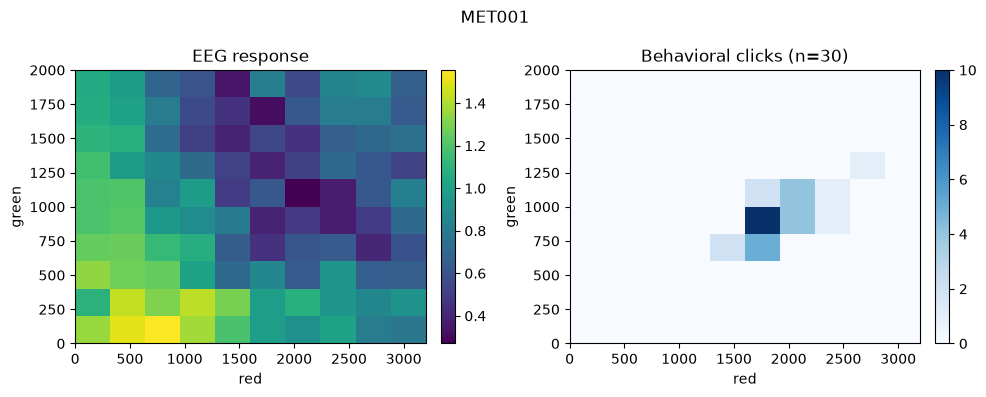

In [2]:
sub_id = 'MET001'
E = analysis.mean_grid(runmap_df, baselines_df, sub_id, session, normalize=analysis.DEFAULT_NORMALIZE)
plotting.plot_overlap(beh_df, E, [sub_id], title=sub_id);

In [3]:
overlap.subject_overlap(beh_df, runmap_df, baselines_df, sub_id, session, n_perm=5000, seed=0)

{'p_value': 0.0098,
 'obs_stat': 0.4384506989369529,
 'null_stats': array([1.11714066, 1.06151137, 0.63323125, ..., 1.23533762, 0.6661433 ,
        0.61778085], shape=(5000,))}

## Group overlap: HC, PD, CVD, protan, deutan

Each group's clicks pooled into one density map, EEG grids averaged
(`mean_grid_across_subjects`) into one response map, one permutation test
per group (per-subject tests would need combining afterward; pooling first
gives one clean group-level answer, same choice `beh/`'s group plots
already make).

In [4]:
categories = [
    ('HC', dict(group='CTR')),
    ('PD', dict(group='PD')),
    ('CVD', dict(group='CVD')),
    ('protan', dict(group='CVD', subgroup='protan')),
    ('deutan', dict(group='CVD', subgroup='deutan')),
]

rows = []
for label, kw in categories:
    r = overlap.group_overlap(beh_df, runmap_df, baselines_df, metadata_df, session, n_perm=5000, seed=0, **kw)
    rows.append({'group': label, 'n': r['n_subjects'], 'obs_stat': r['obs_stat'], 'p_value': r['p_value']})
group_results = pd.DataFrame(rows)
group_results

,group,n,obs_stat,p_value
0,HC,21,0.328522,0.0098
1,PD,6,0.321599,0.0408
2,CVD,15,0.231454,0.0208
3,protan,8,0.177840,0.0208
4,deutan,7,0.146565,0.0098


**Every group's behavioral clicks concentrate where the EEG response is
low, significantly more than a toroidal-shift null predicts (p<0.05 for
all five)** -- including HC. That's consistent with the metamer hypothesis
holding even for healthy participants, not just as a CVD-specific signal --
directly relevant to the researcher's question of whether subtle
color-vision trends are visible in HC data too.

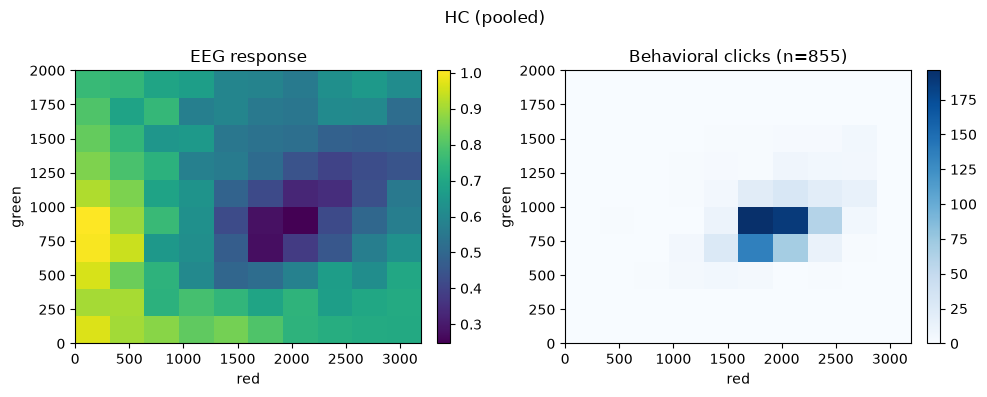

In [5]:
E_ctr = analysis.group_grid(runmap_df, baselines_df, metadata_df, session, group='CTR', normalize=analysis.DEFAULT_NORMALIZE)
ctr_subs = analysis.subjects_in_group(metadata_df, session, group='CTR')
plotting.plot_overlap(beh_df, E_ctr, ctr_subs, title='HC (pooled)');

## A second, simpler metric: behavioral centroid vs. EEG trough distance

Complements the density-overlap test with one interpretable number per
subject: how far is a participant's mean behavioral click from their own
EEG trough location (argmin)?

In [6]:
rows = []
for sub_id in overlap_subs:
    r = overlap.centroid_distance(beh_df, runmap_df, baselines_df, sub_id, session)
    group = metadata_df.loc[(metadata_df['sub_id'] == sub_id) & (metadata_df['session'] == session), 'group'].iloc[0]
    rows.append({'sub_id': sub_id, 'group': group, **r})
distance_table = pd.DataFrame(rows)
distance_table.groupby('group')['distance'].agg(['count', 'mean', 'median'])

,count,mean,median
group,,,
CTR,21,421.672740,308.372353
CVD,15,788.780815,621.826752
HD,1,64.351412,64.351412
PD,6,406.478076,320.019747


CVD's behavioral-centroid-to-EEG-trough distance (mean ~789) is roughly
twice HC's (~422) and PD's (~406) -- consistent with CVD participants'
perceived color match diverging more from the EEG's minimal-response point,
plausibly because their own EEG trough estimate is less reliable to begin
with (`ssveps/`'s M6 finding that CVD trough fits are more likely to peg at
the sampled range boundary).

## Suggested further ways of testing this relationship

Not built in this M1 pass (kept scoped to the two methods above per
project decision), but worth pursuing next:

1. **Orientation correlation** -- `beh/`'s PCA line orientation
   (`features.subject_shape_features`'s `orientation_deg`, which perfectly
   separates protan from deutan, M2) vs. `ssveps/`'s `analysis.fit_ramp`
   slope direction (`slope_red`/`slope_green`) -- both are independent
   "which way does the deficiency point" measures from different
   modalities; do they agree?
2. **Click-value permutation** -- instead of density-weighted spatial
   overlap, a simpler one-sample test: is the EEG value *at* clicked cells
   lower than a null of random same-count cells (skips the toroidal-shift
   machinery entirely)?
3. **Cross-session reliability** -- for subjects with repeat sessions in
   both modalities, is the overlap/distance relationship itself stable
   session to session (extends `ssveps/`'s M5/M9 reliability theme across
   modalities)?